In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings to keep output clean
warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models' / 'behavior_encoder'
VISUALS_DIR = PROJECT_ROOT / 'visualizations'

# Ensure directories exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:

print("\n[*] Loading Master Behavior Dataset...")
behavior_path = PROCESSED_DATA_DIR / 'master_behavior_data.csv'
df_behavior = pd.read_csv(behavior_path)

print("[*] Preparing data for Neural Training...")
# Separate features (X) and target label (y)
X = df_behavior.drop(columns=['label'])

# Encode labels: 1 for Network_Attack, 0 for Safe
y = df_behavior['label'].apply(lambda x: 1 if x == 'Network_Attack' else 0)

# Split into 80% Training and 20% Testing
# stratify=y ensures the 80/20 split maintains the same ratio of 'Attack' vs 'Safe' cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f" -> Training Samples: {X_train.shape[0]}")
print(f" -> Testing Samples:  {X_test.shape[0]}")


[*] Loading Master Behavior Dataset...
[*] Preparing data for Neural Training...
 -> Training Samples: 80000
 -> Testing Samples:  20000


In [3]:
print("\n[*] Scaling features...")
scaler = StandardScaler()

# Fit the scaler on training data, then transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


[*] Scaling features...


In [4]:
print("\n[*] Training Advanced RandomForest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, 
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)
print("[SUCCESS] Initial Training Complete.")


[*] Training Advanced RandomForest Classifier...
[SUCCESS] Initial Training Complete.


In [5]:
print("\n[*] Starting Hyperparameter Tuning with GridSearchCV...")
print(" -> Note: This might take a few minutes as it tests multiple combinations.")

param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees in the forest
    'max_depth': [None, 10, 20],         # Maximum depth of each tree
    'min_samples_split': [2, 5]          # Minimum number of samples required to split an internal node
}

# Create a base model
base_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Run Grid Search (Cross-Validation = 3)
# We use f1_macro scoring because it balances precision and recall
grid_search = GridSearchCV(
    estimator=base_rf, 
    param_grid=param_grid, 
    cv=3, 
    n_jobs=-1, 
    scoring='f1_macro', 
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n[SUCCESS] Tuning Complete!")
print(f" -> Best Hyperparameters Found: {grid_search.best_params_}")
print(f" -> Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Update our model to the BEST model found
best_rf_model = grid_search.best_estimator_


[*] Starting Hyperparameter Tuning with GridSearchCV...
 -> Note: This might take a few minutes as it tests multiple combinations.
Fitting 3 folds for each of 18 candidates, totalling 54 fits

[SUCCESS] Tuning Complete!
 -> Best Hyperparameters Found: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
 -> Best Cross-Validation F1-Score: 0.9938



[*] Evaluating Model Performance...
 FINAL ACCURACY: 99.3850%
 -> Detailed Classification Report:

                    precision    recall  f1-score   support

          Safe (0)       1.00      0.99      0.99     10000
Network_Attack (1)       0.99      1.00      0.99     10000

          accuracy                           0.99     20000
         macro avg       0.99      0.99      0.99     20000
      weighted avg       0.99      0.99      0.99     20000


[*] Generating & Saving Confusion Matrix...


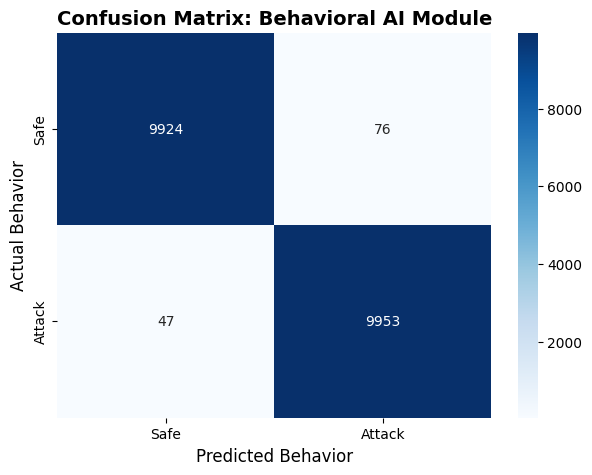

[*] Exporting Trained AI Brain and Scaler to Production...

[SUCCESS] AI Module 1 (Behavioral) trained and saved successfully!
 -> Model Path: c:\Users\induw\OneDrive\Documents\SENTIO_360_Project\models\behavior_encoder\rf_behavior_model.pkl
 -> Scaler Path: c:\Users\induw\OneDrive\Documents\SENTIO_360_Project\models\behavior_encoder\behavior_scaler.pkl


In [6]:

print("\n[*] Evaluating Model Performance...")
# Use the best model found from GridSearch
y_pred = best_rf_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f" FINAL ACCURACY: {acc * 100:.4f}%")

print(" -> Detailed Classification Report:\n")
# The report shows Precision, Recall, and F1-score for both classes
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Network_Attack (1)']))



print("\n[*] Generating & Saving Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Attack'], yticklabels=['Safe', 'Attack'])
plt.title('Confusion Matrix: Behavioral AI Module', fontsize=14, fontweight='bold')
plt.ylabel('Actual Behavior', fontsize=12)
plt.xlabel('Predicted Behavior', fontsize=12)
plt.savefig(VISUALS_DIR / '04_behavior_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("[*] Exporting Trained AI Brain and Scaler to Production...")
model_path = MODELS_DIR / 'rf_behavior_model.pkl'
scaler_path = MODELS_DIR / 'behavior_scaler.pkl'

# Save the model and the scaler
joblib.dump(best_rf_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n[SUCCESS] AI Module 1 (Behavioral) trained and saved successfully!")
print(f" -> Model Path: {model_path}")
print(f" -> Scaler Path: {scaler_path}")